In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score
from sklearn.compose import ColumnTransformer

In [21]:
df = pd.read_csv('Train.csv',usecols=['Age','Fare','Survived'])

In [22]:
df.dropna(inplace=True)

In [23]:
X = df.iloc[:,1:]
y = df.iloc[:,0]

In [24]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=30)

In [25]:
clf = DecisionTreeClassifier()

In [26]:
clf.fit(X_train,y_train)
y_pred = clf.predict(X_test)

In [27]:

accuracy_score(y_test,y_pred)

0.6573426573426573

In [28]:
np.mean(cross_val_score(DecisionTreeClassifier(),X,y,cv=10,scoring='accuracy'))

np.float64(0.6275234741784037)

In [37]:
from sklearn.preprocessing import KBinsDiscretizer

kbin_age = KBinsDiscretizer(n_bins=15, encode='ordinal', strategy='quantile', quantile_method='averaged_inverted_cdf')
kbin_fare = KBinsDiscretizer(n_bins=15, encode='ordinal', strategy='quantile', quantile_method='averaged_inverted_cdf')


In [42]:
trf = ColumnTransformer([
    ('first',kbin_age,[0]),
    ('second',kbin_fare,[1])
])


In [43]:
X_train_trf = trf.fit_transform(X_train)
X_test_trf = trf.transform(X_test)

trf.named_transformers_['first'].bin_edges_

array([array([ 0.42,  6.  , 16.  , 18.  , 21.  , 23.  , 25.  , 27.  , 29.  ,
              31.  , 34.  , 36.  , 40.5 , 46.  , 53.  , 80.  ])             ],
      dtype=object)

In [44]:
output = pd.DataFrame({
    'age':X_train['Age'],
    'age_trf':X_train_trf[:,0],
    'fare':X_train['Fare'],
    'fare_trf':X_train_trf[:,1]
})

In [45]:
output['age_labels'] = pd.cut(x=X_train['Age'],
                                    bins=trf.named_transformers_['first'].bin_edges_[0].tolist())
output['fare_labels'] = pd.cut(x=X_train['Fare'],
                                    bins=trf.named_transformers_['second'].bin_edges_[0].tolist())


In [46]:
output.sample(5)

,age,age_trf,fare,fare_trf,age_labels,fare_labels
487,58.0,14.0,29.7000,10.0,"(53.0, 80.0]","(26.288, 30.696]"
423,28.0,7.0,14.4000,7.0,"(27.0, 29.0]","(13.0, 16.1]"
730,29.0,8.0,211.3375,14.0,"(27.0, 29.0]","(90.0, 512.329]"
405,34.0,10.0,21.0000,8.0,"(31.0, 34.0]","(16.1, 24.15]"
102,21.0,4.0,77.2875,13.0,"(18.0, 21.0]","(66.6, 90.0]"


In [47]:
clf = DecisionTreeClassifier()
clf.fit(X_train_trf,y_train)
y_pred2 = clf.predict(X_test_trf)

In [48]:
accuracy_score(y_test,y_pred2)

0.6923076923076923

In [49]:
X_trf = trf.fit_transform(X)
np.mean(cross_val_score(DecisionTreeClassifier(),X,y,cv=10,scoring='accuracy'))

np.float64(0.6330985915492957)

In [50]:
def discretize(bins,strategy):
    kbin_age = KBinsDiscretizer(n_bins=bins,encode='ordinal',strategy=strategy)
    kbin_fare = KBinsDiscretizer(n_bins=bins,encode='ordinal',strategy=strategy)
    
    trf = ColumnTransformer([
        ('first',kbin_age,[0]),
        ('second',kbin_fare,[1])
    ])
    
    X_trf = trf.fit_transform(X)
    print(np.mean(cross_val_score(DecisionTreeClassifier(),X,y,cv=10,scoring='accuracy')))
    
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    plt.hist(X['Age'])
    plt.title("Before")

    plt.subplot(122)
    plt.hist(X_trf[:,0],color='red')
    plt.title("After")

    plt.show()
    
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    plt.hist(X['Fare'])
    plt.title("Before")

    plt.subplot(122)
    plt.hist(X_trf[:,1],color='red')
    plt.title("Fare")

    plt.show()
    

0.6303208137715179


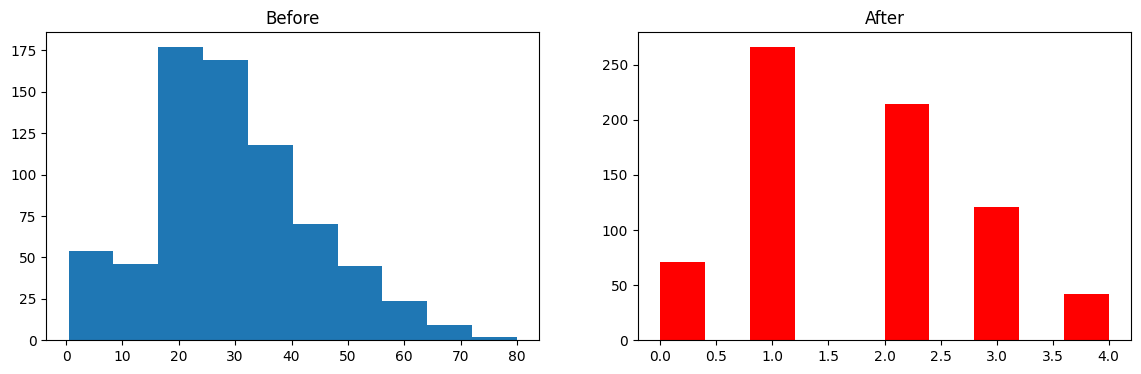

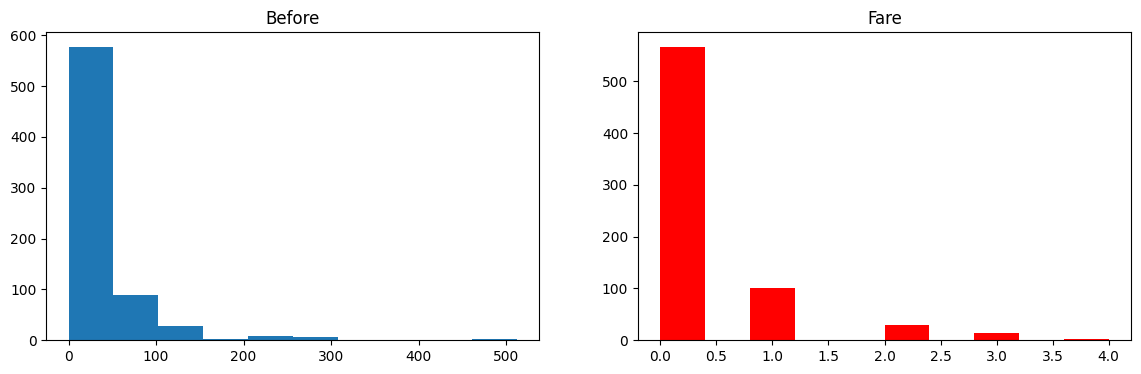

In [ ]:
#KMEANS
discretize(5,'kmeans')

0.6344874804381846


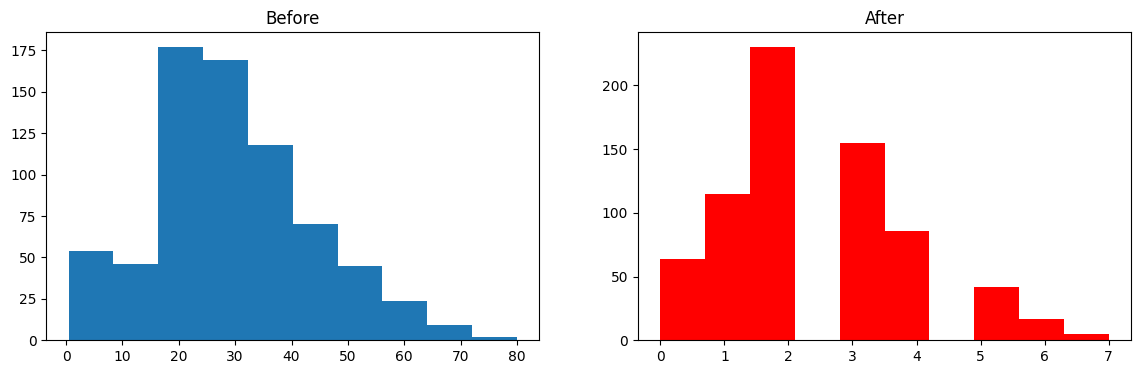

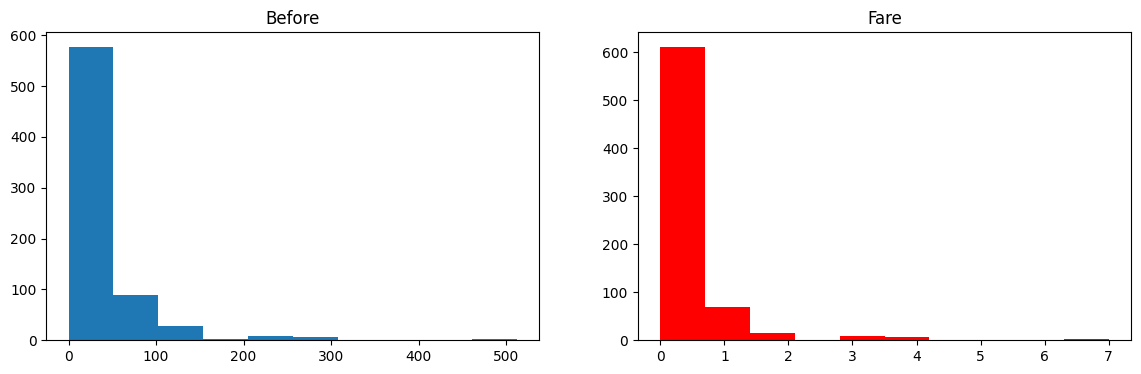

In [54]:
# uniform
discretize(8,'uniform')

c:\Users\Preethika\anaconda3\Lib\site-packages\sklearn\preprocessing\_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
c:\Users\Preethika\anaconda3\Lib\site-packages\sklearn\preprocessing\_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


0.6303599374021909


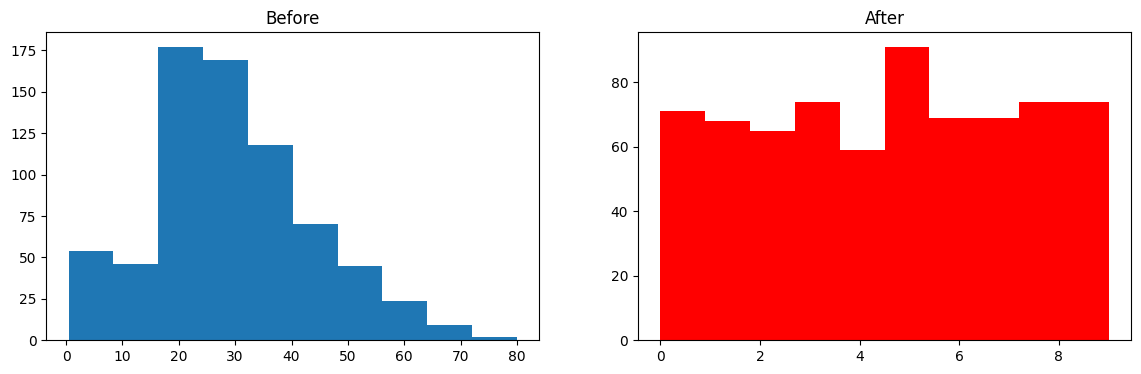

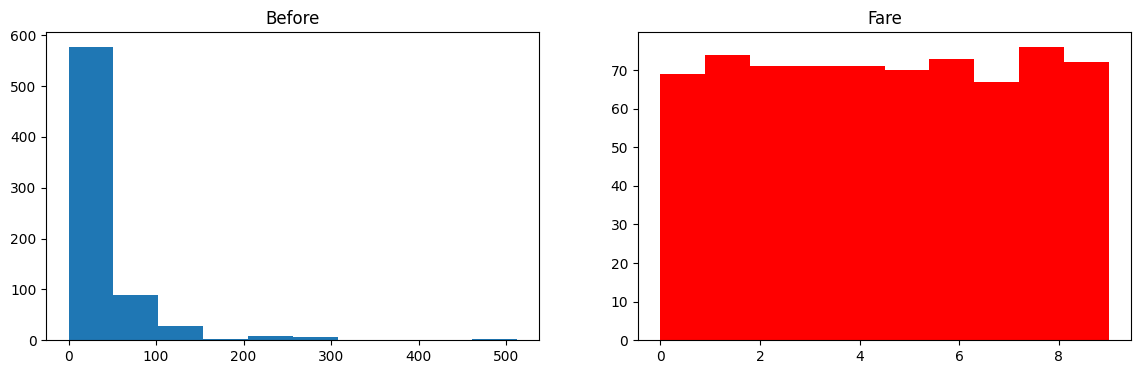

In [53]:
#Quantile
discretize(10,'quantile')